In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglikebasic
import modeselector
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 15
e0 = 0.4 
# NOTE: BELOW FIXED
xI0 = 1.0
dist = 0.25 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# NOTE: change verbose argument for debugging
loglike_obj = loglikebasic.LogLike(params_star, 
                                   waveform_gen_comb, 
                                   gwf, 
                                   mode_select = [(2, -2, 0), (2, -2, -1), (2, -2, 1), (3, -3, -1), (3, -3, 1)],
                                   verbose=False, 
                                   waveform_gen_sep=waveform_gen_sep, 
                                   )

print('Done initializing loglike class.')
print("Setting up log_density and prior functions...")
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


with open('cov_matrix_2yr.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

sigmas = np.sqrt(np.diag(cov_matrix))
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike

    return log_likes

def prior_transform(u):
    # 30x 2 yr fisher box
    # logm1lim = [5.993644400065664, 6.006355599934336]
    # logm2lim = [1.4695178717993715, 1.4847246376399532]
    # alim = [0.6738220486297384, 0.7261779513702615]
    # p0lim = [14.819785641762511, 15.180214358237489]
    # e0lim = [0.3966578164843461, 0.40334218351565393]

     # fisher box
    # logm1lim = [5.999915258667542, 6.000084741332458]
    # logm2lim = [1.4770198762807252, 1.4772226331585996]
    # alim = [0.6996509606483965, 0.7003490393516034]
    # p0lim = [14.997597141890166, 15.002402858109834]
    # e0lim = [0.3999554375531246, 0.4000445624468754]

    # dynamic
    # n = 10
    logm1lim = [param_true[0] - 1*sigmas[0], param_true[0] + 1*sigmas[0]]
    logm2lim = [param_true[1] - 300*sigmas[1], param_true[1] + 300*sigmas[1]]
    alim = [param_true[2] - 50*sigmas[2], param_true[2] + 50*sigmas[2]]
    p0lim = [param_true[3] - 1*sigmas[3], param_true[3] + 1*sigmas[3]]
    e0lim = [param_true[4] - 5*sigmas[4], param_true[4] + 5*sigmas[4]]

    # broaden to 2-5x wider
    # logm1lim = [param_true[0] - 5*sigmas[0], param_true[0] + 5*sigmas[0]]
    # logm2lim = [param_true[1] - 500*sigmas[1], param_true[1] + 500*sigmas[1]]
    # alim = [param_true[2] - 100*sigmas[2], param_true[2] + 100*sigmas[2]]
    # p0lim = [param_true[3] - 3*sigmas[3], param_true[3] + 3*sigmas[3]]
    # e0lim = [param_true[4] - 10*sigmas[4], param_true[4] + 10*sigmas[4]]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    
print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Setting up log_density and prior functions...
Calculating SNR...
SNR calculated: 9.267655351245015
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
log_density(np.array([param_true]))

array([2.79749246])

In [3]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
logden_list = sampler.searched_log_densities_list

In [6]:
np.argmax(logden_list)

2697

In [7]:
np.max(logden_list)

2.7971440474978255

In [8]:
point_max = sampler.searched_points_list[0][np.argmax(logden_list)]
point_max

array([0.36250297, 0.4986549 , 0.50037491, 0.49826853, 0.59670876])

In [9]:
param_max = prior_transform(np.array([point_max]))
param_max

array([[ 5.9999767 ,  1.47703944,  0.70001309, 14.99999168,  0.4000431 ]])

In [10]:
param_true

[6.0, 1.4771212547196624, 0.7, 15, 0.4]

In [11]:
math.dist(param_max[0], param_true)

9.661815573844614e-05

In [12]:
# param_ranges = [(5.993644400065664, 6.006355599934336),
#     (1.4695178717993715, 1.4847246376399532),
#     (0.6738220486297384, 0.7261779513702615),
#    (14.819785641762511, 15.180214358237489),
#     (0.3966578164843461, 0.40334218351565393)]

# param_ranges = [(5.999915258667542, 6.000084741332458), 
#                 (1.4770198762807252, 1.4772226331585996),
#                 (0.6996509606483965, 0.7003490393516034),
#                 (14.997597141890166, 15.002402858109834),
#                 (0.3999554375531246, 0.4000445624468754)
#                 ]

param_ranges = [(param_true[0] - 1*sigmas[0], param_true[0] + 1*sigmas[0]),
                (param_true[1] - 300*sigmas[1], param_true[1] + 300*sigmas[1]),
                (param_true[2] - 50*sigmas[2], param_true[2] + 50*sigmas[2]),
                (param_true[3] - 1*sigmas[3], param_true[3] + 1*sigmas[3]),
                (param_true[4] - 5*sigmas[4], param_true[4] + 5*sigmas[4])
                ]
# n=50
# param_ranges = [(param_true[0] - 5*sigmas[0], param_true[0] + 5*sigmas[0]),
#                 (param_true[1] - 500*sigmas[1], param_true[1] + 500*sigmas[1]),
#                 (param_true[2] - 100*sigmas[2], param_true[2] + 100*sigmas[2]),
#                 (param_true[3] - 3*sigmas[3], param_true[3] + 3*sigmas[3]),
#                 (param_true[4] - 10*sigmas[4], param_true[4] + 10*sigmas[4])
#                 ]

In [13]:
param_ranges

[(5.999915258667542, 6.000084741332458),
 (1.4467077230384986, 1.5075347864008262),
 (0.6825480324198256, 0.7174519675801743),
 (14.997597141890166, 15.002402858109834),
 (0.3997771877656231, 0.40022281223437695)]

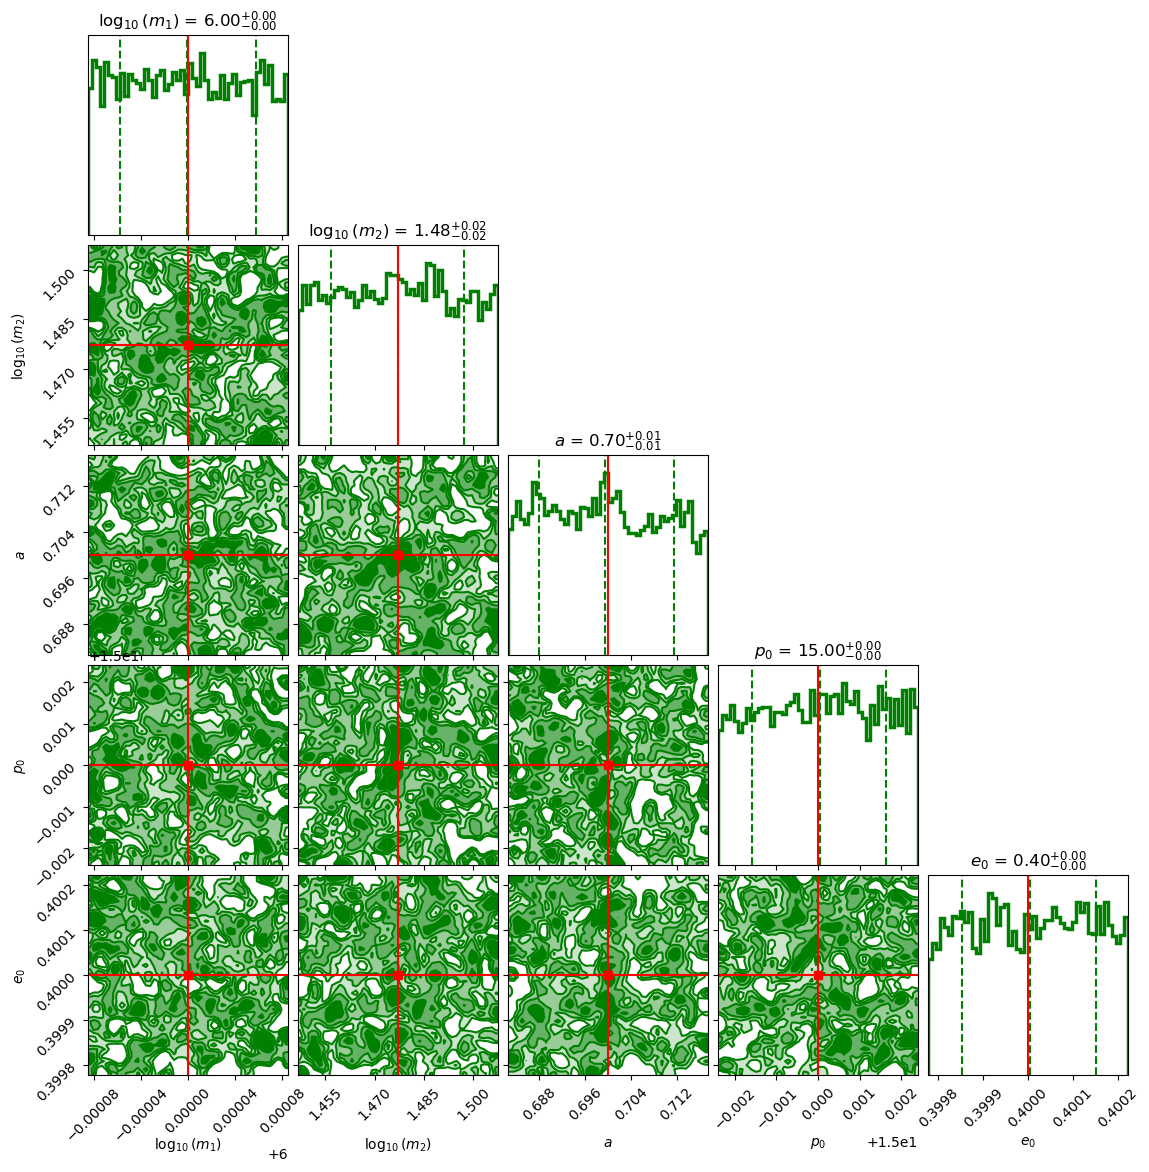

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

In [15]:
log_density(np.array([param_true]))

array([2.79749246])